# Hafta 11 - MNIST ile K-Means Siniflandirma

Bu notebook, MNIST handwritten digit veri seti uzerinde K-Means ile siniflandirma denemesi yapar.

Hedefler:
- MNIST veri setini indirmek ve onbellege almak,
- Ornek rakam goruntulerini incelemek,
- PCA ile boyut azaltma yapmak,
- K-Means cikislarini rakam etiketlerine esleyip performansi degerlendirmek.

Not:
- K-Means dogrudan ham 784 boyutlu piksellerde calistirildiğinde yavaslayabilir.
- Bu nedenle oncelikle PCA ile daha kucuk bir ozellik uzayi kullanacagiz.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

np.random.seed(42)
sns.set_theme(style="whitegrid", palette="Set2")

DATA_DIR = Path("hafta11kMeans")
CACHE_FILE = DATA_DIR / "mnist_784.npz"
DATA_DIR.mkdir(exist_ok=True)

print(f"Veri klasoru: {DATA_DIR.resolve()}")
print(f"Onbellek dosyasi: {CACHE_FILE.resolve()}")

Veri klasoru: /home/onc/workspace/dersler/2526/ileri_programlama/hafta11kMeans
Onbellek dosyasi: /home/onc/workspace/dersler/2526/ileri_programlama/hafta11kMeans/mnist_784.npz


## 1. MNIST veri setini yukleme

Veri seti ilk calistirmada internetten indirilir ve `hafta11kMeans/mnist_784.npz` dosyasina kaydedilir.

MNIST:
- 70.000 adet 28x28 gri tonlamali rakam goruntusu,
- Her goruntu 784 pikselden olusur,
- Etiketler 0 ile 9 arasindaki rakamlardir.

In [2]:
if CACHE_FILE.exists():
    cached = np.load(CACHE_FILE)
    X = cached["X"]
    y = cached["y"]
    print("Veri onbellekten yuklendi.")
else:
    mnist = fetch_openml("mnist_784", version=1, as_frame=False)
    X = mnist.data.astype(np.float32) / 255.0
    y = mnist.target.astype(np.int64)
    np.savez_compressed(CACHE_FILE, X=X, y=y)
    print("Veri indirildi ve onbellege kaydedildi.")

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)
print("Siniflar:", np.unique(y))

Veri indirildi ve onbellege kaydedildi.
X boyutu: (70000, 784)
y boyutu: (70000,)
Siniflar: [0 1 2 3 4 5 6 7 8 9]


## 2. Veri setine hizli bakis

Birkac rakam ornegini cizerek veri setinin yapisini gorelim ve sinif dagilimini kontrol edelim.

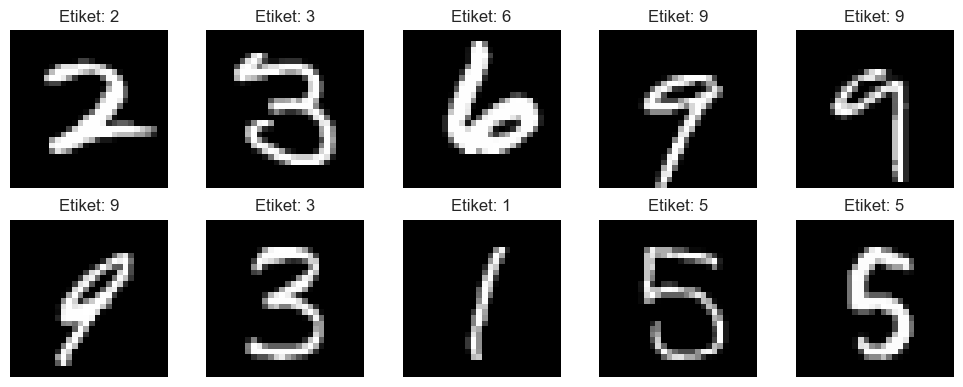

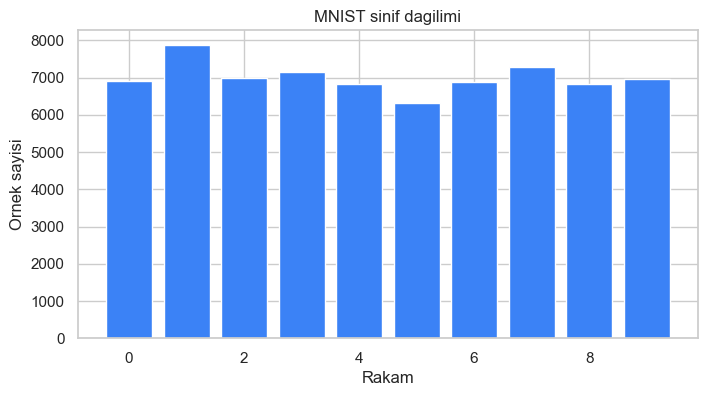

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
indices = np.random.choice(len(X), size=10, replace=False)
for axis, idx in zip(axes.ravel(), indices):
    axis.imshow(X[idx].reshape(28, 28), cmap="gray")
    axis.set_title(f"Etiket: {y[idx]}")
    axis.axis("off")
plt.tight_layout()
plt.show()

counts = np.bincount(y)
plt.figure(figsize=(8, 4))
plt.bar(np.arange(len(counts)), counts, color="#3b82f6")
plt.title("MNIST sinif dagilimi")
plt.xlabel("Rakam")
plt.ylabel("Ornek sayisi")
plt.show()

## 3. PCA ile boyut azaltma

K-Means, ozellik sayisi arttikca daha yavas calisir. Bu nedenle veriyi PCA ile kucultup hem hiz hem de gürültü azalimi elde edecegiz.

Burada PCA'yi egitim verisinde ogretecek ve geri kalan bolumleri ayni donusumden gecirecegiz.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=20000,
    test_size=5000,
    random_state=42,
    stratify=y,
)

pca = PCA(n_components=750, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Egitim veri boyutu:", X_train.shape)
print("Test veri boyutu:", X_test.shape)
print("PCA sonrasi boyut:", X_train_pca.shape)
print("Toplam aciklanan varyans orani:", pca.explained_variance_ratio_.sum())

Egitim veri boyutu: (20000, 784)
Test veri boyutu: (5000, 784)
PCA sonrasi boyut: (20000, 750)
Toplam aciklanan varyans orani: 0.99999994


## 4. K-Means modeli

K-Means dogrudan rakam etiketlerini bilmez. Bu nedenle once kümeleri ogretip, sonra her kume icin egitim verisindeki baskin rakami etiket olarak kullanacagiz.

In [ ]:
kmeans = KMeans(n_clusters=10, random_state=42 )
kmeans.fit(X_train_pca)
train_clusters = kmeans.labels_

def build_cluster_mapping(cluster_ids, labels, n_clusters=10):
    contingency = np.zeros((n_clusters, 10), dtype=int)
    for cluster_id in range(n_clusters):
        mask = cluster_ids == cluster_id
        if np.any(mask):
            contingency[cluster_id] = np.bincount(labels[mask], minlength=10)

    row_ind, col_ind = linear_sum_assignment(-contingency)
    mapping = {cluster_id: -1 for cluster_id in range(n_clusters)}
    for cluster_id, digit in zip(row_ind, col_ind):
        mapping[int(cluster_id)] = int(digit)
    return mapping, contingency

cluster_to_digit, contingency = build_cluster_mapping(train_clusters, y_train)
print("Kume -> rakam eslestirmesi:", cluster_to_digit)

def map_clusters_to_digits(cluster_ids, mapping):
    return np.array([mapping[cluster_id] for cluster_id in cluster_ids])

y_train_pred = map_clusters_to_digits(train_clusters, cluster_to_digit)
train_accuracy = accuracy_score(y_train, y_train_pred)

X_test_clusters = kmeans.predict(X_test_pca)
y_test_pred = map_clusters_to_digits(X_test_clusters, cluster_to_digit)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Egitim dogrulugu:", train_accuracy)
print("Test dogrulugu:", test_accuracy)
print(classification_report(y_test, y_test_pred, zero_division=0))

ValueError: could not broadcast input array from shape (10,) into shape (8,)

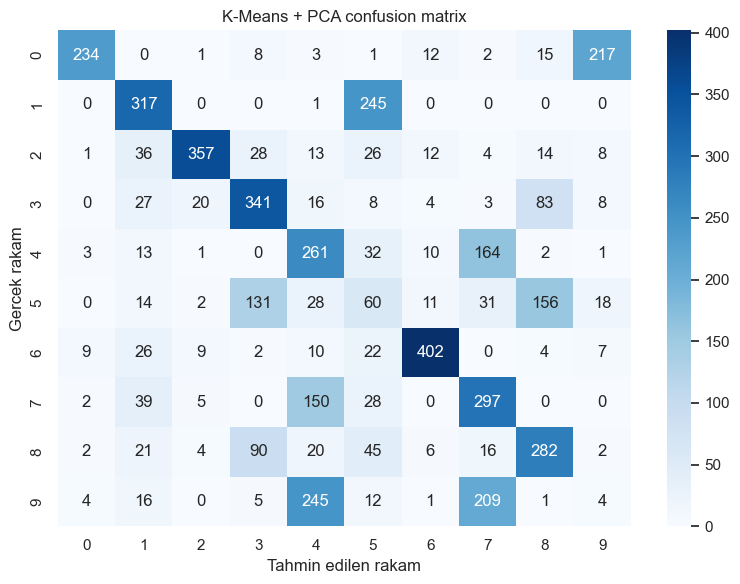

In [27]:
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("K-Means + PCA confusion matrix")
plt.xlabel("Tahmin edilen rakam")
plt.ylabel("Gercek rakam")
plt.tight_layout()
plt.show()

## 5. Kisa yorum

- PCA, K-Means'in daha hizli ve daha kararlı calismasina yardim eder.
- K-Means etiketli bir model degildir; bu yuzden kume-sonuc eslestirmesi icin egitim verisindeki baskin rakami kullandik.
- Confusion matrix, hangi rakamlarin birbiriyle daha cok karistigini gostermeye yardim eder.

Isterseniz bir sonraki adimda bu notebook'a `MiniBatchKMeans` ya da farkli PCA bileşen sayisi denemeleri de ekleyebilirim.